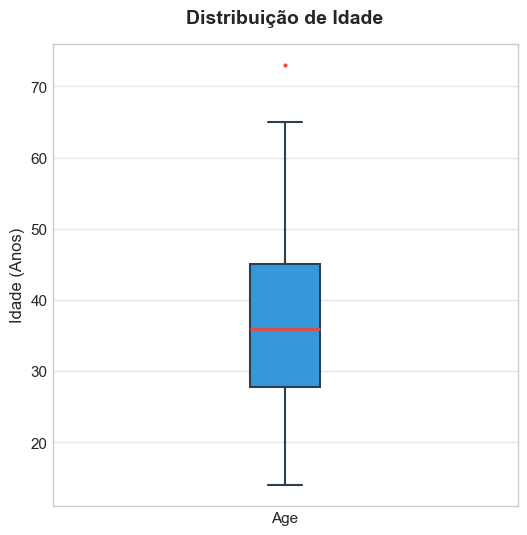

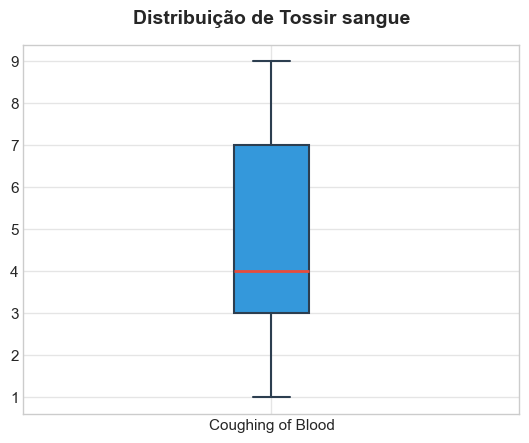

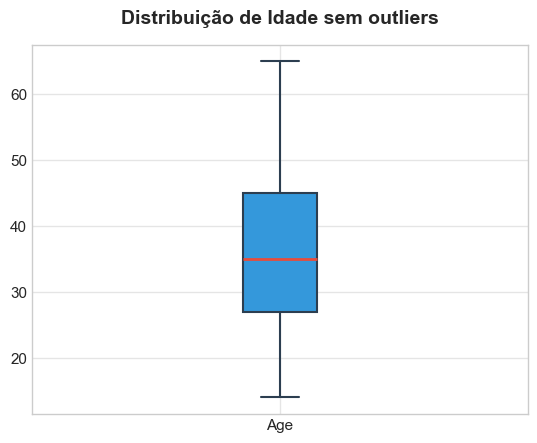

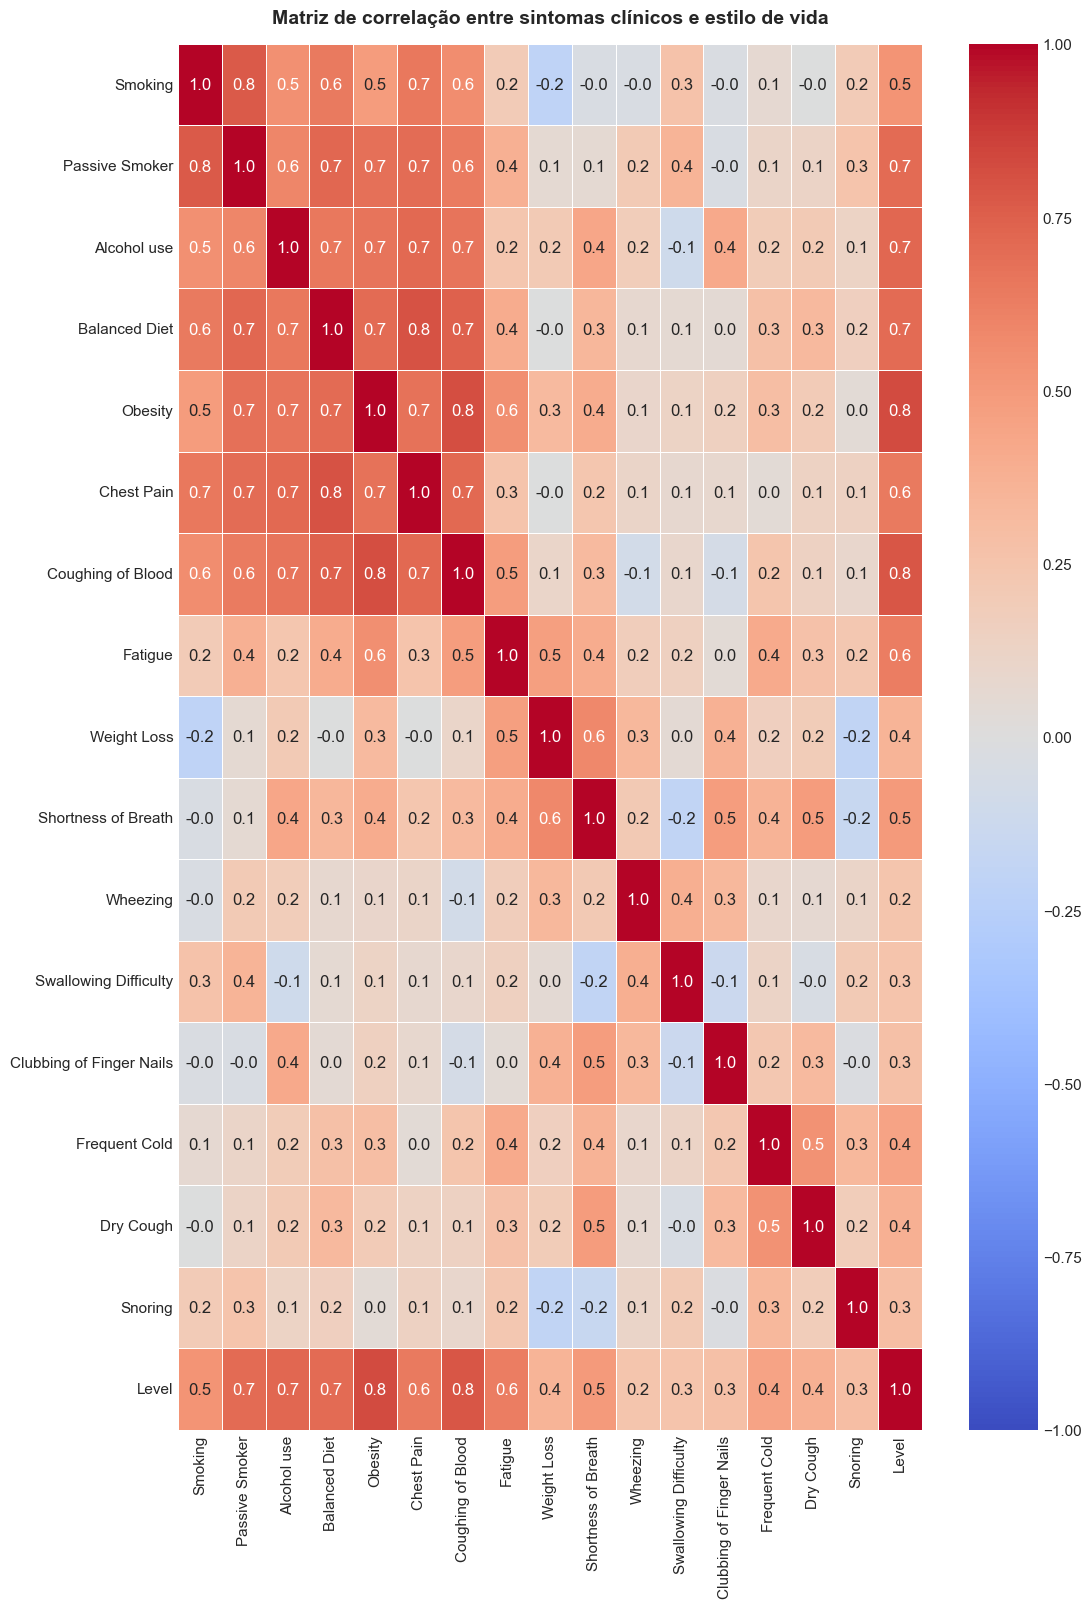

O número total de homens com o risco máximo de câncer de pulmão é:  252
O número total de pessoas que fumam e bebem:  285


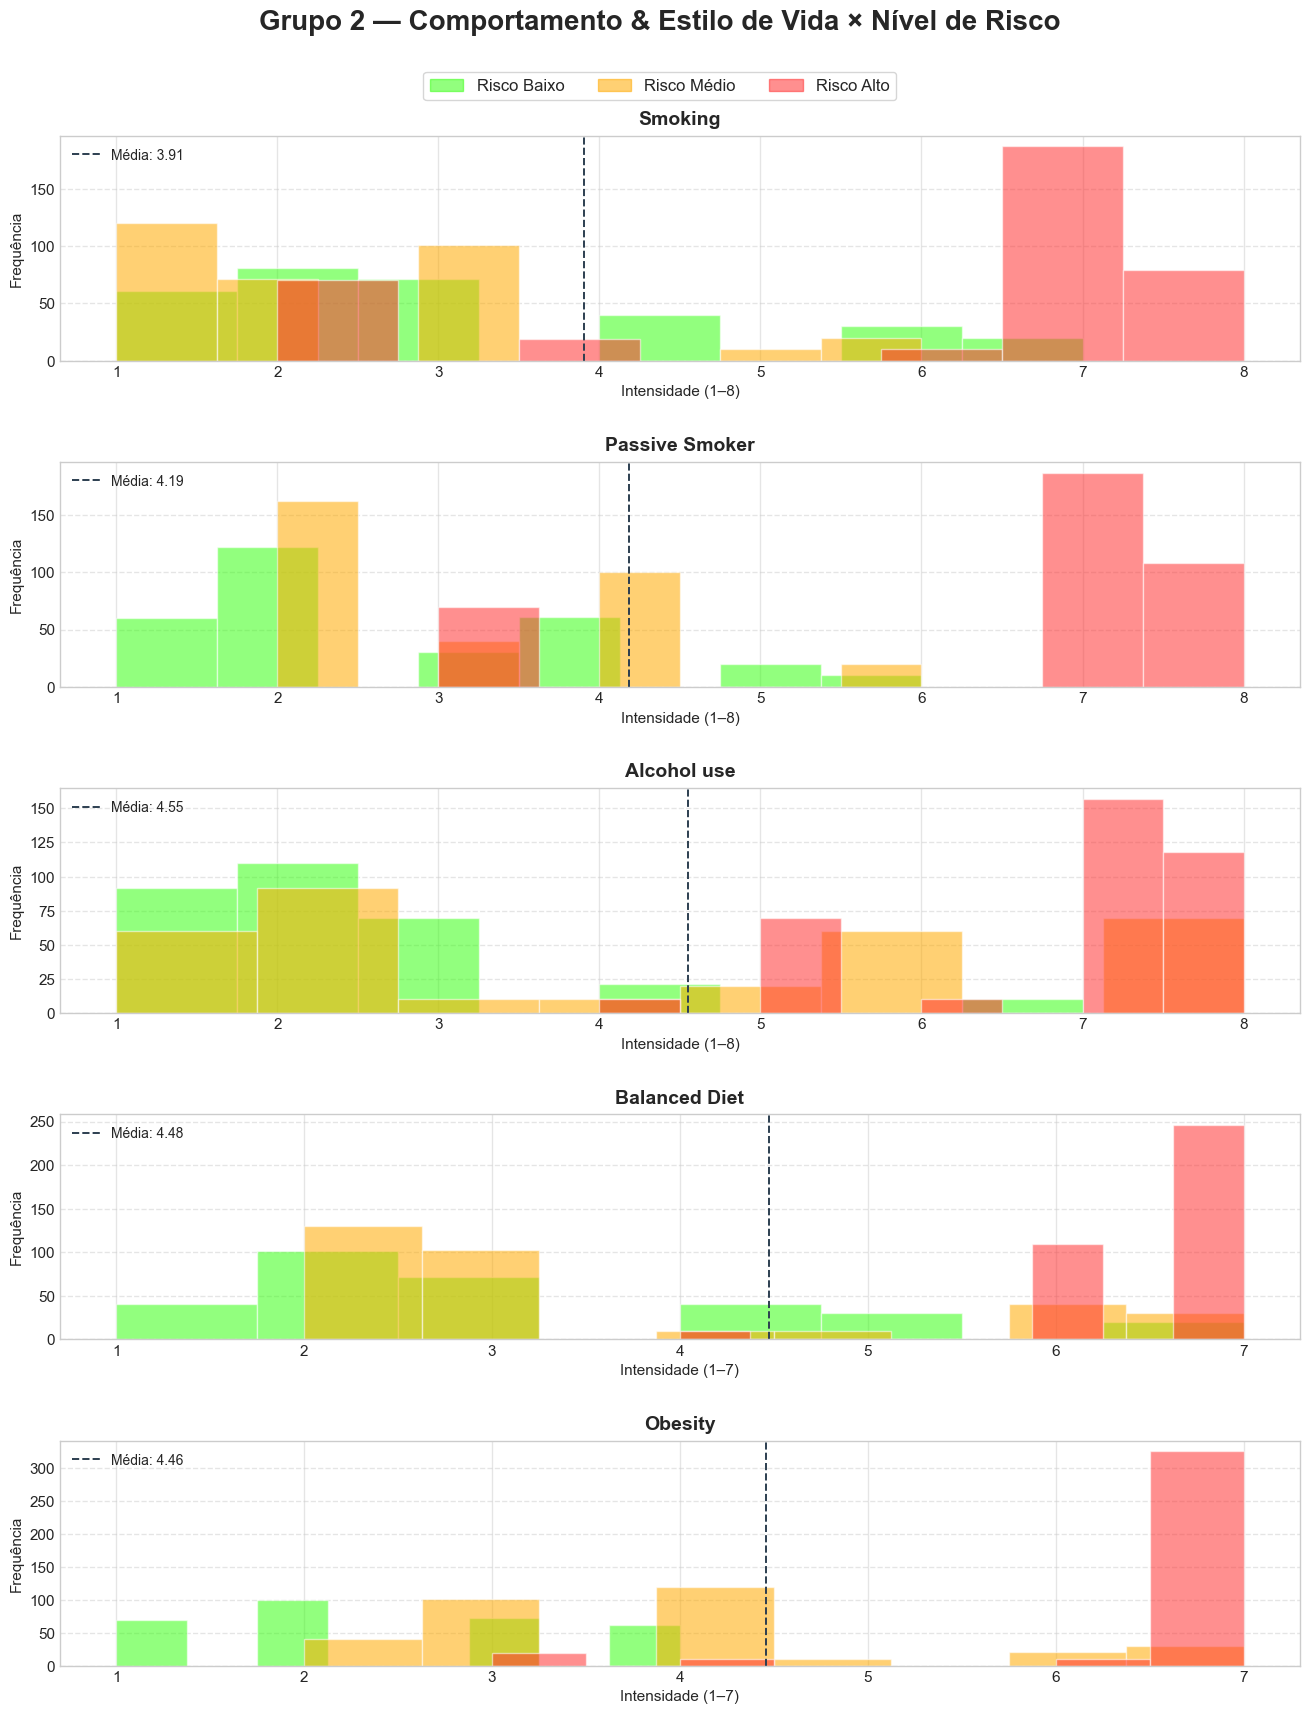

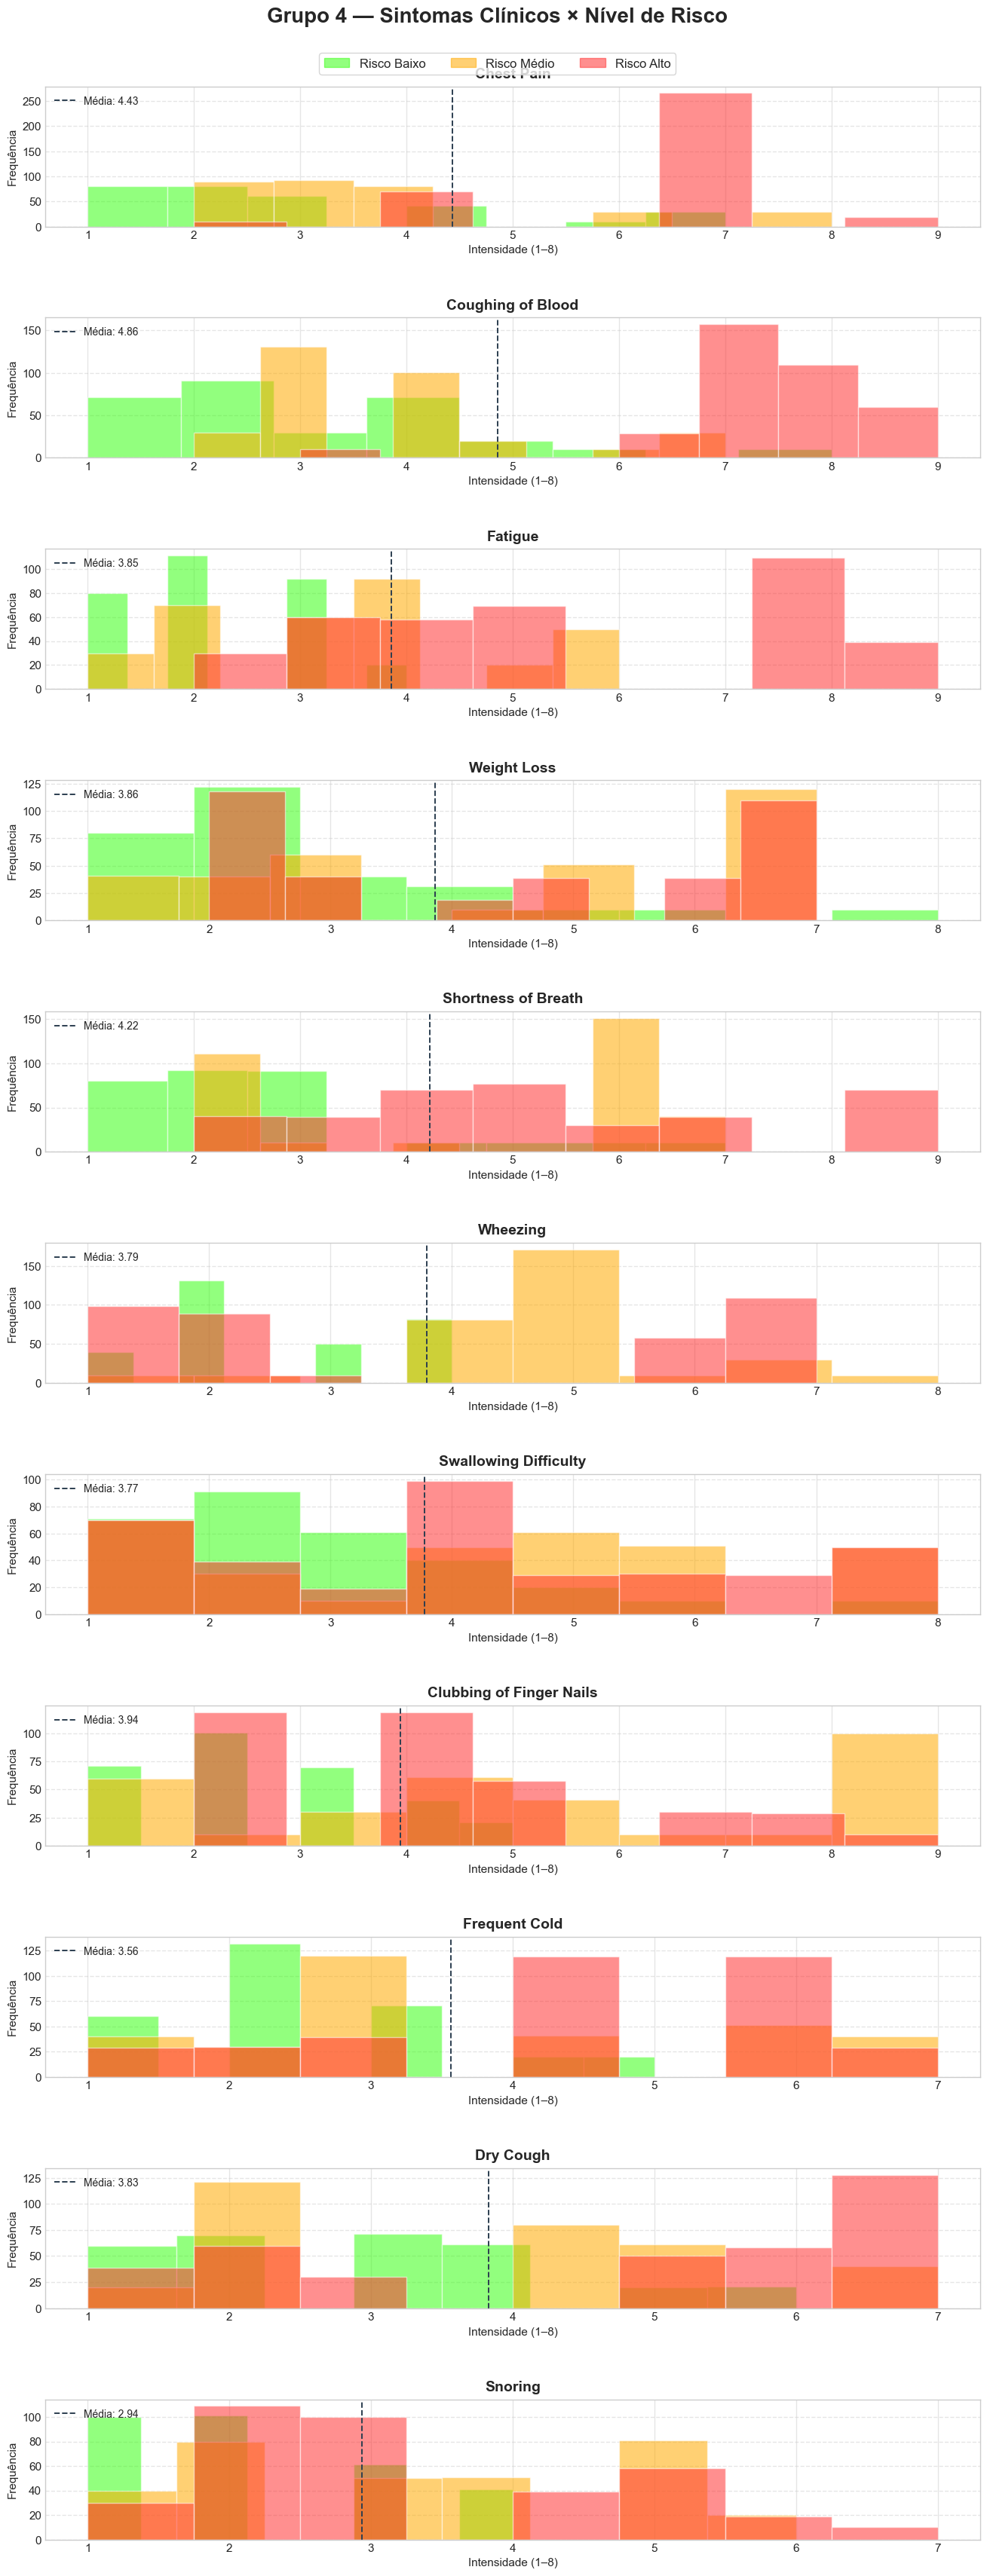

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import skew
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

df_1 = pd.read_csv('Dataset(1).csv', index_col='index')
plt.style.use('seaborn-v0_8-whitegrid')
#df_1.head()
#df_1.info()

#DUPLICADOS - SEM DUPLICADOS
#duplicados = df_1[df_1.duplicated(keep='first')]
#print(duplicados)

#VENDO SE TEM NaN - NÃO TEM NAN
#check_null = pd.isnull(df_1)
#print(check_null) #- Sem nulos. check null retornou false, portanto sem nulos.

#Descobrimos que os registros após 999 são todos preenchidos por zeros. Quando se faz a checagem dos valores nulos eles passam despercebidos.

#REMOVENDO OS ZEROS - TINHA, REGISTROS APOS O 999
df_1 = df_1[df_1['Patient Id'] != '0']

#Transformar level em valor numérico
mapa = {'Low': 0, 'Medium': 1, 'High': 2}
df_1['Level'] = df_1['Level'].map(mapa)

#OUTLIERS
#gráfico dificil de compreender, porem ajudou a achar os valores 0s
#sns.scatterplot(x=range(len(df_1['Age'])), y=df_1['Age'])
#plt.title("Scatter Plot for Age")
#plt.show()

plt.figure(figsize=(6, 6))
df_1.boxplot(column='Age',
             patch_artist=True,
             ax=plt.gca(), # Garante que ele desenhe na figura atual isolada
             boxprops=dict(facecolor='#3498db', color='#2c3e50', linewidth=1.5),
             whiskerprops=dict(color='#2c3e50', linewidth=1.5),
             capprops=dict(color='#2c3e50', linewidth=1.5),
             medianprops=dict(color='#e74c3c', linewidth=2),
             flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=4))
plt.title('Distribuição de Idade', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Idade (Anos)', fontsize=12)
plt.grid(axis='x')

plt.show()
print("\n\n")
#Verificando em Coughing of Blood - não tem
df_1.boxplot(column='Coughing of Blood', patch_artist=True,
             boxprops=dict(facecolor='#3498db', color='#2c3e50', linewidth=1.5),
             whiskerprops=dict(color='#2c3e50', linewidth=1.5),
             capprops=dict(color='#2c3e50', linewidth=1.5),
             medianprops=dict(color='#e74c3c', linewidth=2),
             flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6))
plt.title('Distribuição de Tossir sangue', fontsize=14, fontweight='bold', pad=15)
plt.show()

print("\n\n")

#Vendo os limites superiores, inferiores e quartis
q1 = df_1['Age'].quantile(0.25)
q3 = df_1['Age'].quantile(0.75)
IQR = q3-q1
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
outliers = df_1[(df_1['Age'] < lower_limit) | (df_1['Age'] > upper_limit)]
#print(f'Outliers encontrados:\n{outliers}')

#Removendo os outliers
df_sem_outlier = df_1[(df_1['Age'] >= lower_limit) & (df_1['Age'] <= upper_limit)]
#print(len(df_1))
#print(len(df_sem_outlier))
df_1 = df_sem_outlier

df_1.boxplot(column='Age', patch_artist=True,
             boxprops=dict(facecolor='#3498db', color='#2c3e50', linewidth=1.5),
             whiskerprops=dict(color='#2c3e50', linewidth=1.5),
             capprops=dict(color='#2c3e50', linewidth=1.5),
             medianprops=dict(color='#e74c3c', linewidth=2),
             flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6))
plt.title('Distribuição de Idade sem outliers', fontsize=14, fontweight='bold', pad=15)
plt.show()
#df_1.to_csv("Dataset(1).csv")

#Verificando os parametros
df_1.max()

print("\n\n")

#Matriz de correlação
colunas_selecionadas = ["Smoking", "Passive Smoker", "Alcohol use", "Balanced Diet", "Obesity", "Chest Pain", "Coughing of Blood", "Fatigue", "Weight Loss",
                        "Shortness of Breath", "Wheezing", "Swallowing Difficulty", "Clubbing of Finger Nails", "Frequent Cold", "Dry Cough", "Snoring", "Level"]

matriz = df_1[colunas_selecionadas].corr()
plt.figure(figsize=(12, 18))
sns.heatmap(matriz, annot=True, fmt=".1f", linewidths=.6, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação entre sintomas clínicos e estilo de vida", fontsize=14, fontweight='bold', pad=15)
plt.show()

totalh = len(df_1[(df_1['Gender'] == 1) & (df_1['Level'] == 2)])
print("O número total de homens com o risco máximo de câncer de pulmão é: ", totalh)

totalFumoBebida = len(df_1[(df_1['Smoking'] > 1) & (df_1['Alcohol use'] > 6)])
print("O número total de pessoas que fumam e bebem: ", totalFumoBebida)

# Histograma de relação de Level com o Grupo 2
PALETTE_RISK = ['#39ff14', '#ffaa00', '#ff3333']
LABELS_RISK = ['Risco Baixo', 'Risco Médio', 'Risco Alto']

fig, axes = plt.subplots(5, 1, figsize=(16, 18))
fig.suptitle('Grupo 2 — Comportamento & Estilo de Vida × Nível de Risco',
             fontsize=20, fontweight='bold', y=0.97)

G2_VARS = ['Smoking', 'Passive Smoker', 'Alcohol use', 'Balanced Diet', 'Obesity']

axes_flat = axes.flatten()

for ax, var in zip(axes_flat, G2_VARS):
    for lv in [0, 1, 2]:
        ax.hist(df_1[df_1['Level'] == lv][var], bins=8, alpha=0.55,
                color=PALETTE_RISK[lv], edgecolor='white')

    media = df_1[var].mean()
    ax.axvline(media, color='#2c3e50', linestyle='--', linewidth=1.4,
               label=f'Média: {media:.2f}')

    ax.set_title(var, fontsize=14, fontweight='bold', pad=8)

    escala_max = 7 if var in ['Balanced Diet', 'Obesity'] else 8
    ax.set_xlabel(f'Intensidade (1–{escala_max})', fontsize=11)
    ax.set_ylabel('Frequência', fontsize=11)

    ax.legend(loc='upper left', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

handles_legenda = [plt.Rectangle((0,0),1,1, color=color, alpha=0.55) for color in PALETTE_RISK]
fig.legend(handles_legenda, LABELS_RISK, loc='upper center', bbox_to_anchor=(0.5, 0.94),
           ncol=3, fontsize=12, frameon=True)

plt.subplots_adjust(top=0.90, hspace=0.45, bottom=0.05)
plt.show()

print("\n\n")
#Histograma grupo 4
fig, axes = plt.subplots(11, 1, figsize=(16, 35))
fig.suptitle('Grupo 4 — Sintomas Clínicos × Nível de Risco',
             fontsize=20, fontweight='bold', y=0.98) # Ajustado o y para o topo

G4_VARS = [
    'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss',
    'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty',
    'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring'
]

axes_flat = axes.flatten()

for ax, var in zip(axes_flat, G4_VARS):
    for lv in [0, 1, 2]:
        ax.hist(df_1[df_1['Level'] == lv][var], bins=8, alpha=0.55,
                color=PALETTE_RISK[lv], edgecolor='white')

    media = df_1[var].mean()
    ax.axvline(media, color='#2c3e50', linestyle='--', linewidth=1.4,
               label=f'Média: {media:.2f}')

    ax.set_title(var, fontsize=14, fontweight='bold', pad=8)

    escala_max = 7 if var in ['Balanced Diet', 'Obesity'] else 8
    ax.set_xlabel(f'Intensidade (1–{escala_max})', fontsize=11)
    ax.set_ylabel('Frequência', fontsize=11)

    ax.legend(loc='upper left', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

handles_legenda = [plt.Rectangle((0,0),1,1, color=color, alpha=0.55) for color in PALETTE_RISK]
fig.legend(handles_legenda, LABELS_RISK, loc='upper center', bbox_to_anchor=(0.5, 0.965),
           ncol=3, fontsize=12, frameon=True)

plt.subplots_adjust(top=0.95, hspace=0.65, bottom=0.02)
plt.show()